In [3]:
'''
Моделирование кривой доходности
В этом модуле мы переходим от макроэкономики к финансовым рынкам и управлению процентным риском (Interest Rate Risk). 
Наша главная цель — научиться анализировать временную структуру процентных ставок (Кривую доходности).

Кривая доходности показывает, какую доходность инвесторы требуют от государственных облигаций с разными сроками погашения (от 1 месяца до 30 лет). 
Форма этой кривой:

Нормальная (возрастающая): инвесторы верят в рост экономики и требуют премию за долгосрочный риск.
Инвертированная (убывающая): классический предвестник рецессии (краткосрочные ставки выше долгосрочных).
Какую задачу мы решаем?
У нас есть доходности по 11 разным срокам (матурациям). Работать с 11 связанными переменными неудобно. 
Задача — снизить размерность, то есть сжать эти 11 точек до 3 ключевых факторов, которые управляют кривой.
'''

'\nМоделирование кривой доходности\nВ этом модуле мы переходим от макроэкономики к финансовым рынкам и управлению процентным риском (Interest Rate Risk). \nНаша главная цель — научиться анализировать временную структуру процентных ставок (Кривую доходности).\n\nКривая доходности показывает, какую доходность инвесторы требуют от государственных облигаций с разными сроками погашения (от 1 месяца до 30 лет). \nФорма этой кривой:\n\nНормальная (возрастающая): инвесторы верят в рост экономики и требуют премию за долгосрочный риск.\nИнвертированная (убывающая): классический предвестник рецессии (краткосрочные ставки выше долгосрочных).\nКакую задачу мы решаем?\nУ нас есть доходности по 11 разным срокам (матурациям). Работать с 11 связанными переменными неудобно. \nЗадача — снизить размерность, то есть сжать эти 11 точек до 3 ключевых факторов, которые управляют кривой.\n'

In [5]:
'''
Мы сравним три подхода:

Эконометрический (Модель Нельсона-Сигеля): Классическая математическая функция, которую мы «натянем» на реальные данные методом оптимизации. 
Она постулирует, что кривая состоит из трех факторов: Уровень (Level), Наклон (Slope) и Кривизна (Curvature).
Алгоритмический (Метод главных компонент - PCA): Алгоритм машинного обучения без учителя. Мы не даем ему никаких формул. 
Он сам найдет 3 главных вектора в данных. Спойлер: PCA математически докажет правоту Нельсона и Сигеля, найдя те же самые факторы (сдвиг, наклон, кривизна).
Глубокое обучение (Автоэнкодер): Мы построим нейросеть (Deep Learning), которая сожмет 11 точек в 3 скрытых нейрона, 
а затем попытается восстановить исходную кривую. Это нелинейный подход, который банки используют для поиска аномалий на долговом рынке.
Источники данных
Исторически данные публикуются Казначейством США (U.S. Department of the Treasury) в виде ежедневных отчетов (“Daily Treasury Par Yield Curve Rates”).
Для удобства и сохранения единого конвейера с первым модулем, мы будем скачивать эти же казначейские данные через API FRED. В базе FRED они 
лежат в готовом виде под тикерами DGS1MO, DGS3MO (месяцы) и DGS1 ... DGS30 (годы).
'''

'\nМы сравним три подхода:\n\nЭконометрический (Модель Нельсона-Сигеля): Классическая математическая функция, которую мы «натянем» на реальные данные методом оптимизации. \nОна постулирует, что кривая состоит из трех факторов: Уровень (Level), Наклон (Slope) и Кривизна (Curvature).\nАлгоритмический (Метод главных компонент - PCA): Алгоритм машинного обучения без учителя. Мы не даем ему никаких формул. \nОн сам найдет 3 главных вектора в данных. Спойлер: PCA математически докажет правоту Нельсона и Сигеля, найдя те же самые факторы (сдвиг, наклон, кривизна).\nГлубокое обучение (Автоэнкодер): Мы построим нейросеть (Deep Learning), которая сожмет 11 точек в 3 скрытых нейрона, \nа затем попытается восстановить исходную кривую. Это нелинейный подход, который банки используют для поиска аномалий на долговом рынке.\nИсточники данных\nИсторически данные публикуются Казначейством США (U.S. Department of the Treasury) в виде ежедневных отчетов (“Daily Treasury Par Yield Curve Rates”).\nДля удобс

Размер датасета: (6184, 11)


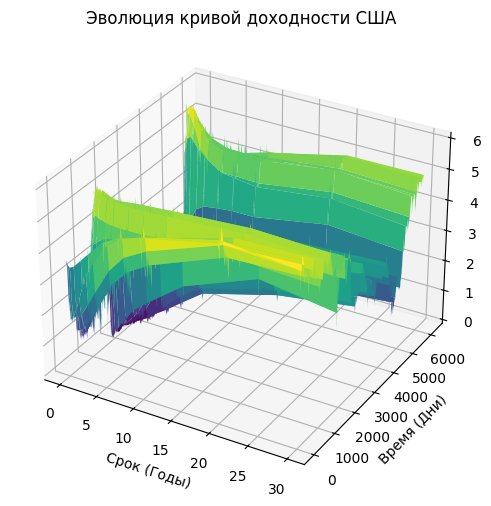

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred

FRED_API_KEY = ''
fred = Fred(api_key=FRED_API_KEY)

treasury_tickers = {
    '1M': 'DGS1MO', '3M': 'DGS3MO', '6M': 'DGS6MO',
    '1Y': 'DGS1', '2Y': 'DGS2', '3Y': 'DGS3', 
    '5Y': 'DGS5', '7Y': 'DGS7', '10Y': 'DGS10', 
    '20Y': 'DGS20', '30Y': 'DGS30'
}

maturities = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])

df_yields = pd.DataFrame()

# TODO 1.2: Напишите цикл для скачивания рядов из FRED, аналогично Модулю 1.
# Сохраняйте ряды в колонки df_yields с именами '1M', '3M' и т.д.
for key in treasury_tickers.keys():
    df_yields[key] = fred.get_series(treasury_tickers[key])

df_yields = df_yields[df_yields.index >= '2000-01-01']
df_yields.dropna(inplace=True)

print("Размер датасета:", df_yields.shape)

# Визуализация 3D: Как кривая менялась во времени
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(maturities, range(len(df_yields)))
ax.plot_surface(X, Y, df_yields.values, cmap='viridis')
ax.set_xlabel('Срок (Годы)')
ax.set_ylabel('Время (Дни)')
ax.set_zlabel('Доходность, %')
plt.title('Эволюция кривой доходности США')
plt.show()


In [14]:
a = np.array([1,2,3])
a*10

array([10, 20, 30])

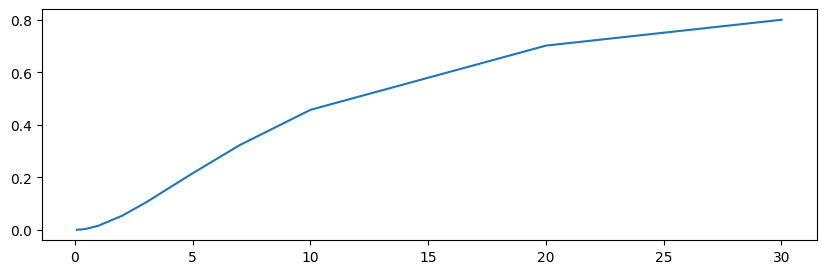

In [36]:
import numpy as np


def nelson_siegel(m, beta0, beta1, beta2, tau):
    # <ВАШ_КОД: реализуйте компоненты формулы>
    term1 = (1 - np.exp(-m/tau)) / (m/tau)
    term2 = ((1 - np.exp(-m/tau)) / (m/tau)) - np.exp(-m/tau)
    return beta0 + beta1 * term1 + beta2 * term2

x = np.array(maturities)
beta0 = 1
beta1 = -1
beta2 = -1
tau = 3
y = nelson_siegel(x, beta0, beta1, beta2, tau)
plt.figure(figsize=(10, 3))
plt.plot(x, y)
plt.show()



In [37]:
test_date = '2020-03-02'
yields_today = df_yields.loc[test_date].values
yields_today

array([1.41, 1.13, 0.95, 0.89, 0.84, 0.85, 0.88, 1.01, 1.1 , 1.46, 1.66])

In [40]:
from scipy.optimize import curve_fit

# TODO 2.1: Реализуйте математическую функцию Нельсона-Сигеля.
# Формула доходности y(m):
# y = beta0 + beta1 * ((1 - exp(-m/tau)) / (m/tau)) + beta2 * (((1 - exp(-m/tau)) / (m/tau)) - exp(-m/tau))
# где m - maturity (срок), tau - параметр затухания, beta0, beta1, beta2 - веса.
def nelson_siegel(m, beta0, beta1, beta2, tau):
    # <ВАШ_КОД: реализуйте компоненты формулы>
    term1 = (1 - np.exp(-m/tau)) / (m/tau)
    term2 = ((1 - np.exp(-m/tau)) / (m/tau)) - np.exp(-m/tau)
    return beta0 + beta1 * term1 + beta2 * term2

# Выберем случайный день для калибровки (например, начало ковидного кризиса)
test_date = '2020-03-02'
yields_today = df_yields.loc[test_date].values

# TODO 2.2: Используйте функцию curve_fit из scipy для поиска оптимальных параметров (beta0, beta1, beta2, tau).
# Передайте ей вашу функцию nelson_siegel, массив сроков maturities и фактические доходности yields_today.
# Функция вернет массив оптимальных параметров (popt).
popt, _ = curve_fit(nelson_siegel, maturities, yields_today)

print(f"Оптимальные параметры на {test_date}:")
print(f"Уровень (b0): {popt[0]:.2f}, Наклон (b1): {popt[1]:.2f}, Кривизна (b2): {popt[2]:.2f}, Tau: {popt[3]:.2f}")

# TODO 2.3: Рассчитайте теоретическую кривую (модельную) с помощью найденных параметров.
# Для этого вызовите nelson_siegel и передайте туда maturities и распакованные параметры *popt.
# yields_modeled = # <ВАШ_КОД>

# plt.figure(figsize=(8, 5))
# plt.plot(maturities, yields_today, 'ro', label='Фактические ставки')
# plt.plot(maturities, yields_modeled, 'b-', label='Nelson-Siegel Model')
# plt.title(f'Калибровка кривой на {test_date}')
# plt.xlabel('Срок до погашения (Годы)')
# plt.ylabel('Доходность, %')
# plt.legend()
# plt.grid(True)
# plt.show()


Оптимальные параметры на 2020-03-02:
Уровень (b0): 1.06, Наклон (b1): -0.04, Кривизна (b2): 4.82, Tau: 0.00


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# TODO 3.1: Стандартизируйте данные (z-score нормализация).
# Обучите StandardScaler на df_yields и трансформируйте данные.
scaler = # <ВАШ_КОД>
yields_scaled = # <ВАШ_КОД>

# TODO 3.2: Инициализируйте PCA с 3 компонентами (n_components=3).
# Обучите модель на масштабированных данных и примените трансформацию (fit_transform).
pca = # <ВАШ_КОД>
pca_factors = # <ВАШ_КОД>

# TODO 3.3: Выведите долю объясненной дисперсии (explained_variance_ratio_) для каждой из 3 компонент.
variance_explained = # <ВАШ_КОД>
print(f"Объясненная дисперсия по компонентам: {variance_explained}")
print(f"Суммарно 3 компоненты объясняют {sum(variance_explained)*100:.2f}% движений рынка!")

# График нагрузок (Loadings) главных компонент на разные сроки погашения.
# Он покажет, что именно нашел алгоритм (Сдвиг, Наклон и Кривизну).
plt.figure(figsize=(10, 5))
plt.plot(maturities, pca.components_[0], label='1 компонента (Уровень/Сдвиг)', marker='o')
plt.plot(maturities, pca.components_[1], label='2 компонента (Наклон)', marker='s')
plt.plot(maturities, pca.components_[2], label='3 компонента (Кривизна)', marker='^')
plt.title('Векторы (Loadings) Метод Главных Компонент')
plt.xlabel('Срок (Годы)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# TODO 4.1: Постройте архитектуру Автоэнкодера (используйте Sequential API).
# 1. Слой Input с формой входа (11,) - по количеству матураций.
# 2. Скрытый (Bottleneck) слой: Dense, 3 нейрона, активация 'relu' или 'linear'.
# 3. Выходной слой: Dense, 11 нейронов, активация 'linear' (восстанавливаем ставки).
autoencoder = Sequential([
    # <ВАШ_КОД: Слой Input>
    # <ВАШ_КОД: Скрытый слой Dense>
    # <ВАШ_КОД: Выходной слой Dense>
])

# TODO 4.2: Скомпилируйте модель. Используйте оптимизатор 'adam' и функцию потерь 'mse' (Mean Squared Error).
# <ВАШ_КОД: autoencoder.compile(...)>

# TODO 4.3: Обучите модель на стандартизированных данных (yields_scaled).
# В автоэнкодерах ВХОД и ВЫХОД - это одни и те же данные!
# epochs=50, batch_size=32, validation_split=0.1
history = # <ВАШ_КОД: autoencoder.fit(X, y, ...)>

# TODO 4.4: Сделайте прогноз (восстановление) кривой на основе yields_scaled с помощью метода predict.
yields_reconstructed = # <ВАШ_КОД: autoencoder.predict(...)>

# Рассчитаем ошибку реконструкции (MSE) для каждого дня.
# Если в какой-то день ошибка аномально высока — это нестандартный шок на рынке (потенциальный инсайд или кризис).
mse_per_day = np.mean(np.power(yields_scaled - yields_reconstructed, 2), axis=1)

df_errors = pd.DataFrame({'Reconstruction_Error': mse_per_day}, index=df_yields.index)

plt.figure(figsize=(12, 4))
plt.plot(df_errors.index, df_errors['Reconstruction_Error'], color='red')
plt.title('Ошибка реконструкции Автоэнкодера (Поиск рыночных аномалий)')
plt.ylabel('MSE')
plt.grid(True)
plt.show()
